In [1]:
# Steps of the workflow

In [46]:
import os
import xarray as xr
import cftime
import matplotlib.pyplot as plt
from utils.utils import autosize_figure, get_scenario_config

In [3]:
# Set a location
lat = 40.5
lon = 105
place = "Fort Collins"

In [4]:
# Starts with hourly surface ozone
DIR1 = "/glade/derecho/scratch/awells/air_quality/CESM2/ozone/hourly_o3"
file1 = "Hourly_surface_o3_CESM2_SSP245_G6_01_2025010100-2035010100.nc"
file_path1 = os.path.join(DIR1, file1)
da1 = xr.open_dataarray(file_path1)

da1_place = da1.sel(lat=lat, lon=lon, method="nearest")

In [11]:
# Next step is MDA8
DIR2 = "/glade/work/awells/air_quality/CESM2/ozone/MDA8"
file2 = "MDA8_CESM2_SSP245_G6_01_202001-208412.nc"
file_path2 = os.path.join(DIR2, file2)
da2 = xr.open_dataarray(file_path2)

da2_place = da2.sel(lat=lat, lon=lon, time=da1_place.time, method="nearest")

In [67]:
# Next is OSDMA8
DIR3 = "/glade/work/awells/air_quality/CESM2/ozone/OSDMA8"
file3 = "OSDMA8_CESM2_SSP245_G6_01_2020-2083.nc"
file_path3 = os.path.join(DIR3, file3)
da3 = xr.open_dataarray(file_path3)

da3_place = da3.sel(lat=lat, lon=lon, method="nearest").sel(year=slice("2025", "2034"))

In [68]:
import cftime
import numpy as np

years = da3_place.year.values.astype(int)

new_time = np.array([
    cftime.DatetimeNoLeap(int(y), 6, 1)
    for y in years
], dtype=object)


da3_place_fixed = (
    da3_place
    .rename({"year": "time"})
    .assign_coords(time=new_time)
)

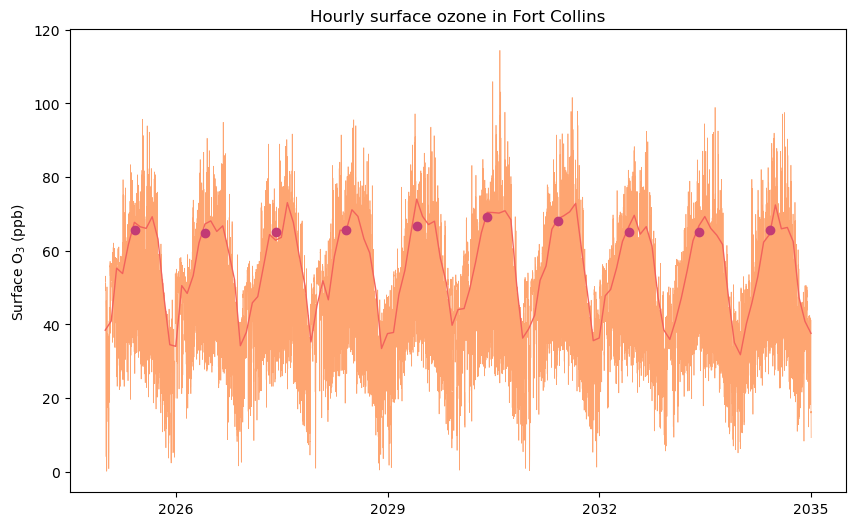

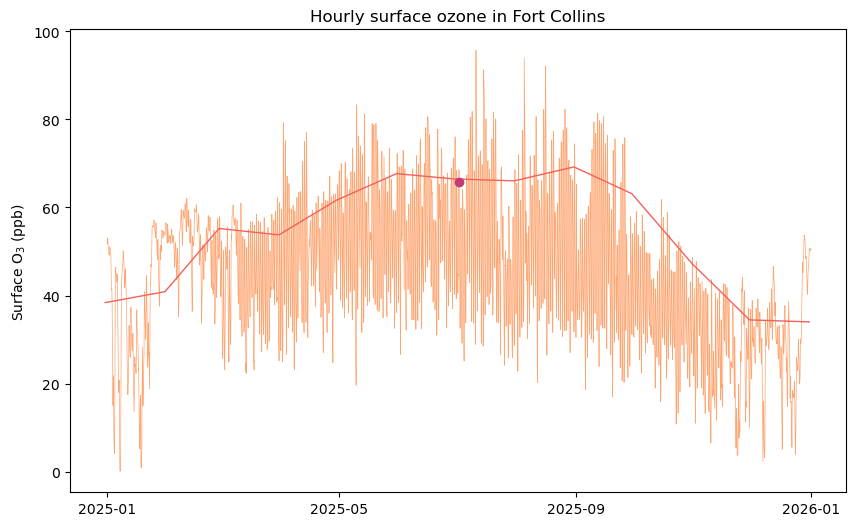

In [90]:
# Full time period
color1 = "#FEA571"
color2 = "#F2625C"
color3 = "#C23B75"

plt.figure(figsize=autosize_figure(1, 1, xscale_factor=1.2))
da1_place.plot(color=color1, lw=0.5)
da2_place.plot(color=color2, lw=1)
da3_place_fixed.plot(marker='o', color=color3, lw=2, ls="")
plt.ylabel("Surface O$_{3}$ (ppb)")
plt.xlabel("")
plt.title(f"Hourly surface ozone in {place}")
plt.show()

# Zoom in on one year
da1_year = da1_place.isel(time=slice(0, 8760))
da2_year = da2_place.isel(time=slice(0, 8760))
da3_year = da3_place_fixed[0]

plt.figure(figsize=autosize_figure(1, 1, xscale_factor=1.2))
da1_year.plot(color=color1, lw=0.5)
da2_year.plot(color=color2, lw=1)
plt.plot(da1_year["time"].isel(time=len(da1_year.time) // 2), da3_year, 'o', color=color3, lw=2)
plt.ylabel("Surface O$_{3}$ (ppb)")
plt.xlabel("")
plt.title(f"Hourly surface ozone in {place}")
plt.show()

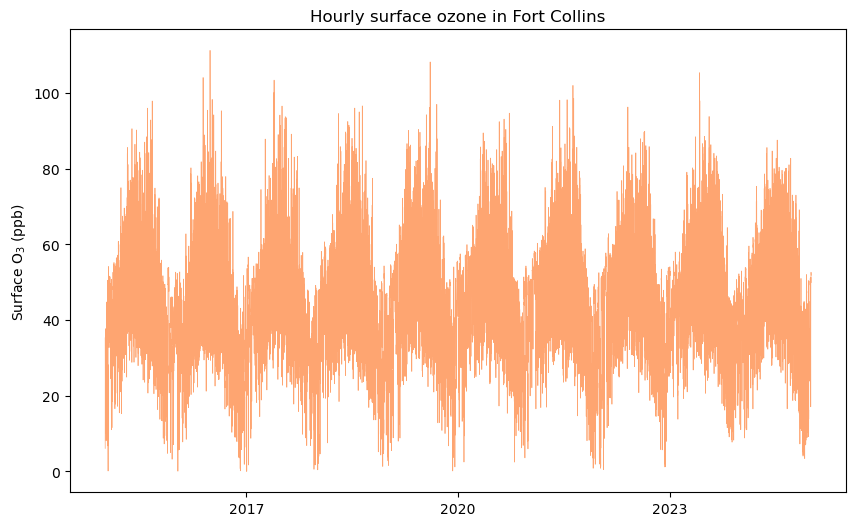

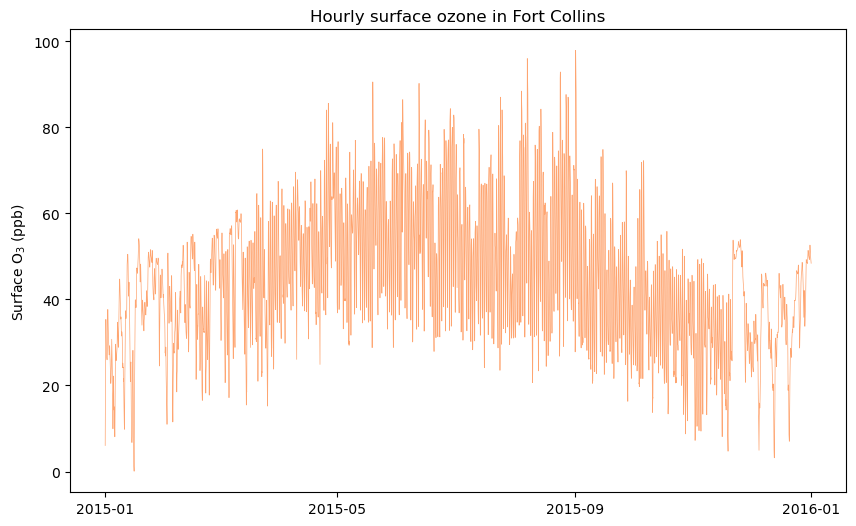

In [20]:
# Full time period
color = "#FEA571"

plt.figure(figsize=autosize_figure(1, 1, xscale_factor=1.2))
da1_place.plot(color=color, lw=0.5)
plt.ylabel("Surface O$_{3}$ (ppb)")
plt.xlabel("")
plt.title(f"Hourly surface ozone in {place}")
plt.show()

# Zoom in on one week
da1_week = da1_place.isel(time=slice(0, 8760))

plt.figure(figsize=autosize_figure(1, 1, xscale_factor=1.2))
da1_week.plot(color=color, lw=0.5)
plt.ylabel("Surface O$_{3}$ (ppb)")
plt.xlabel("")
plt.title(f"Hourly surface ozone in {place}")
plt.show()